# Exercise - Multiple Linear Regression



It's time for you to apply your knowledge to a new dataset. So that not too much changes come at once, we will stick to the cars topic and work with the **car seats data**. A company that makes car seats would like to construct a model to predict sales and they need your help!

You will find the file called `carseats.csv` in the data folder. It contains 400 observations on the following 11 variables:
* **Sales**:         Unit sales (in thousands) at each location
* **CompPrice**:     Price charged by competitor at each location
* **Income**:        Community income level (in thousands of dollars)
* **Advertising**:   Local advertising budget for company at each location (in thousands of dollars)
* **Population**:    Population size in region (in thousands)
* **Price**:         Price company charges for car seats at each site
* **ShelveLoc**:     A factor with levels Bad, Good and Medium indicating the quality of the shelving location for the car seats at each site
* **Age**:           Average age of the local population
* **Education**:     Education level at each location
* **Urban**:         A factor with levels No and Yes to indicate whether the store is in an urban or rural location
* **US**:            A factor with levels No and Yes to indicate whether the store is in the US or not

**(a) Load the data**

In [1]:
import pandas as pd

In [2]:
carseats = pd.read_csv("data/carseats.csv")
carseats.head(n=2)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes


In [3]:
df = carseats

**(b) Visualize the data with the appropriate plots.** 

<br>
<details><summary>
Click here for a hint…
</summary>
Check the documentation for seaborn's pair plots. 
</details>

In [4]:
df.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='str')

In [5]:
df.shape

(400, 11)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
print(df.head())
print(df.dtypes)

   Sales  CompPrice  Income  Advertising  Population  Price ShelveLoc  Age  \
0   9.50        138      73           11         276    120       Bad   42   
1  11.22        111      48           16         260     83      Good   65   
2  10.06        113      35           10         269     80    Medium   59   
3   7.40        117     100            4         466     97    Medium   55   
4   4.15        141      64            3         340    128       Bad   38   

   Education Urban   US  
0         17   Yes  Yes  
1         10   Yes  Yes  
2         12   Yes  Yes  
3         14   Yes  Yes  
4         13   Yes   No  
Sales          float64
CompPrice        int64
Income           int64
Advertising      int64
Population       int64
Price            int64
ShelveLoc          str
Age              int64
Education        int64
Urban              str
US                 str
dtype: object


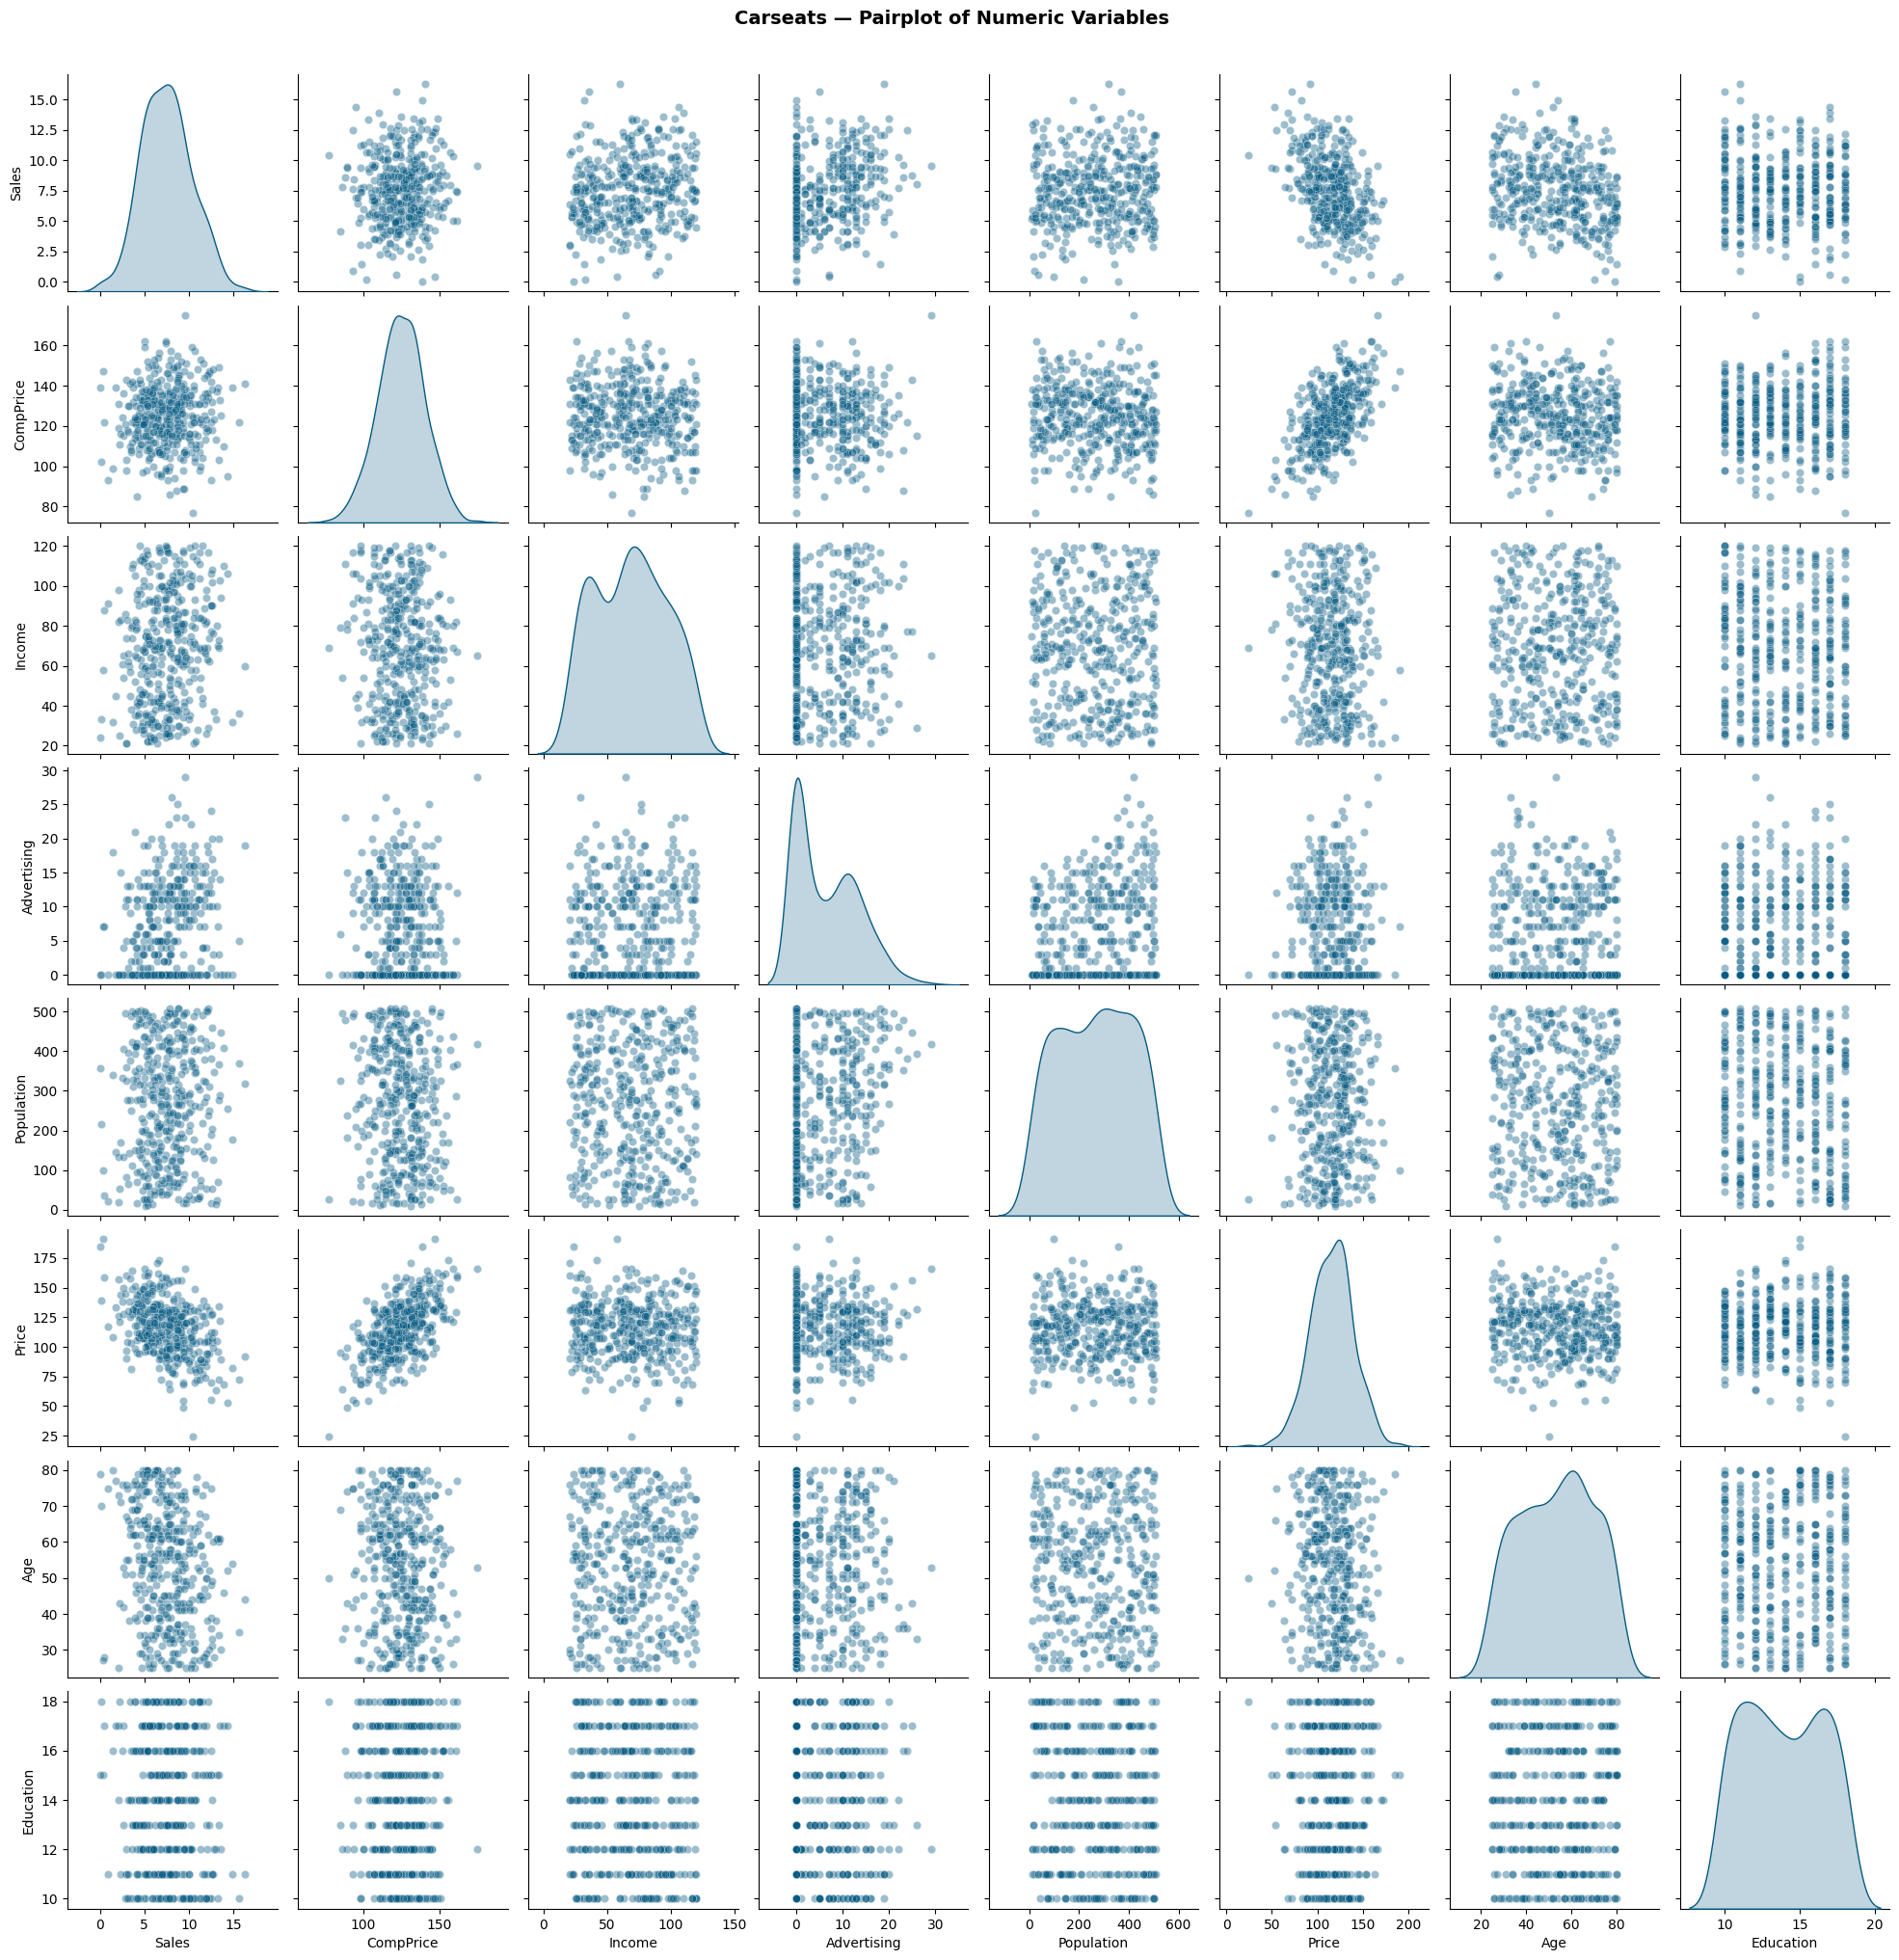

In [8]:
# Select numeric columns only
numeric_cols = ['Sales', 'CompPrice', 'Income', 'Advertising', 
                'Population', 'Price', 'Age', 'Education']

sns.pairplot(df[numeric_cols], 
             diag_kind='kde',        # distribution on diagonal
             plot_kws={'alpha': 0.4, 'color': '#065A82'},
             diag_kws={'color': '#065A82'})

plt.suptitle('Carseats — Pairplot of Numeric Variables', 
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

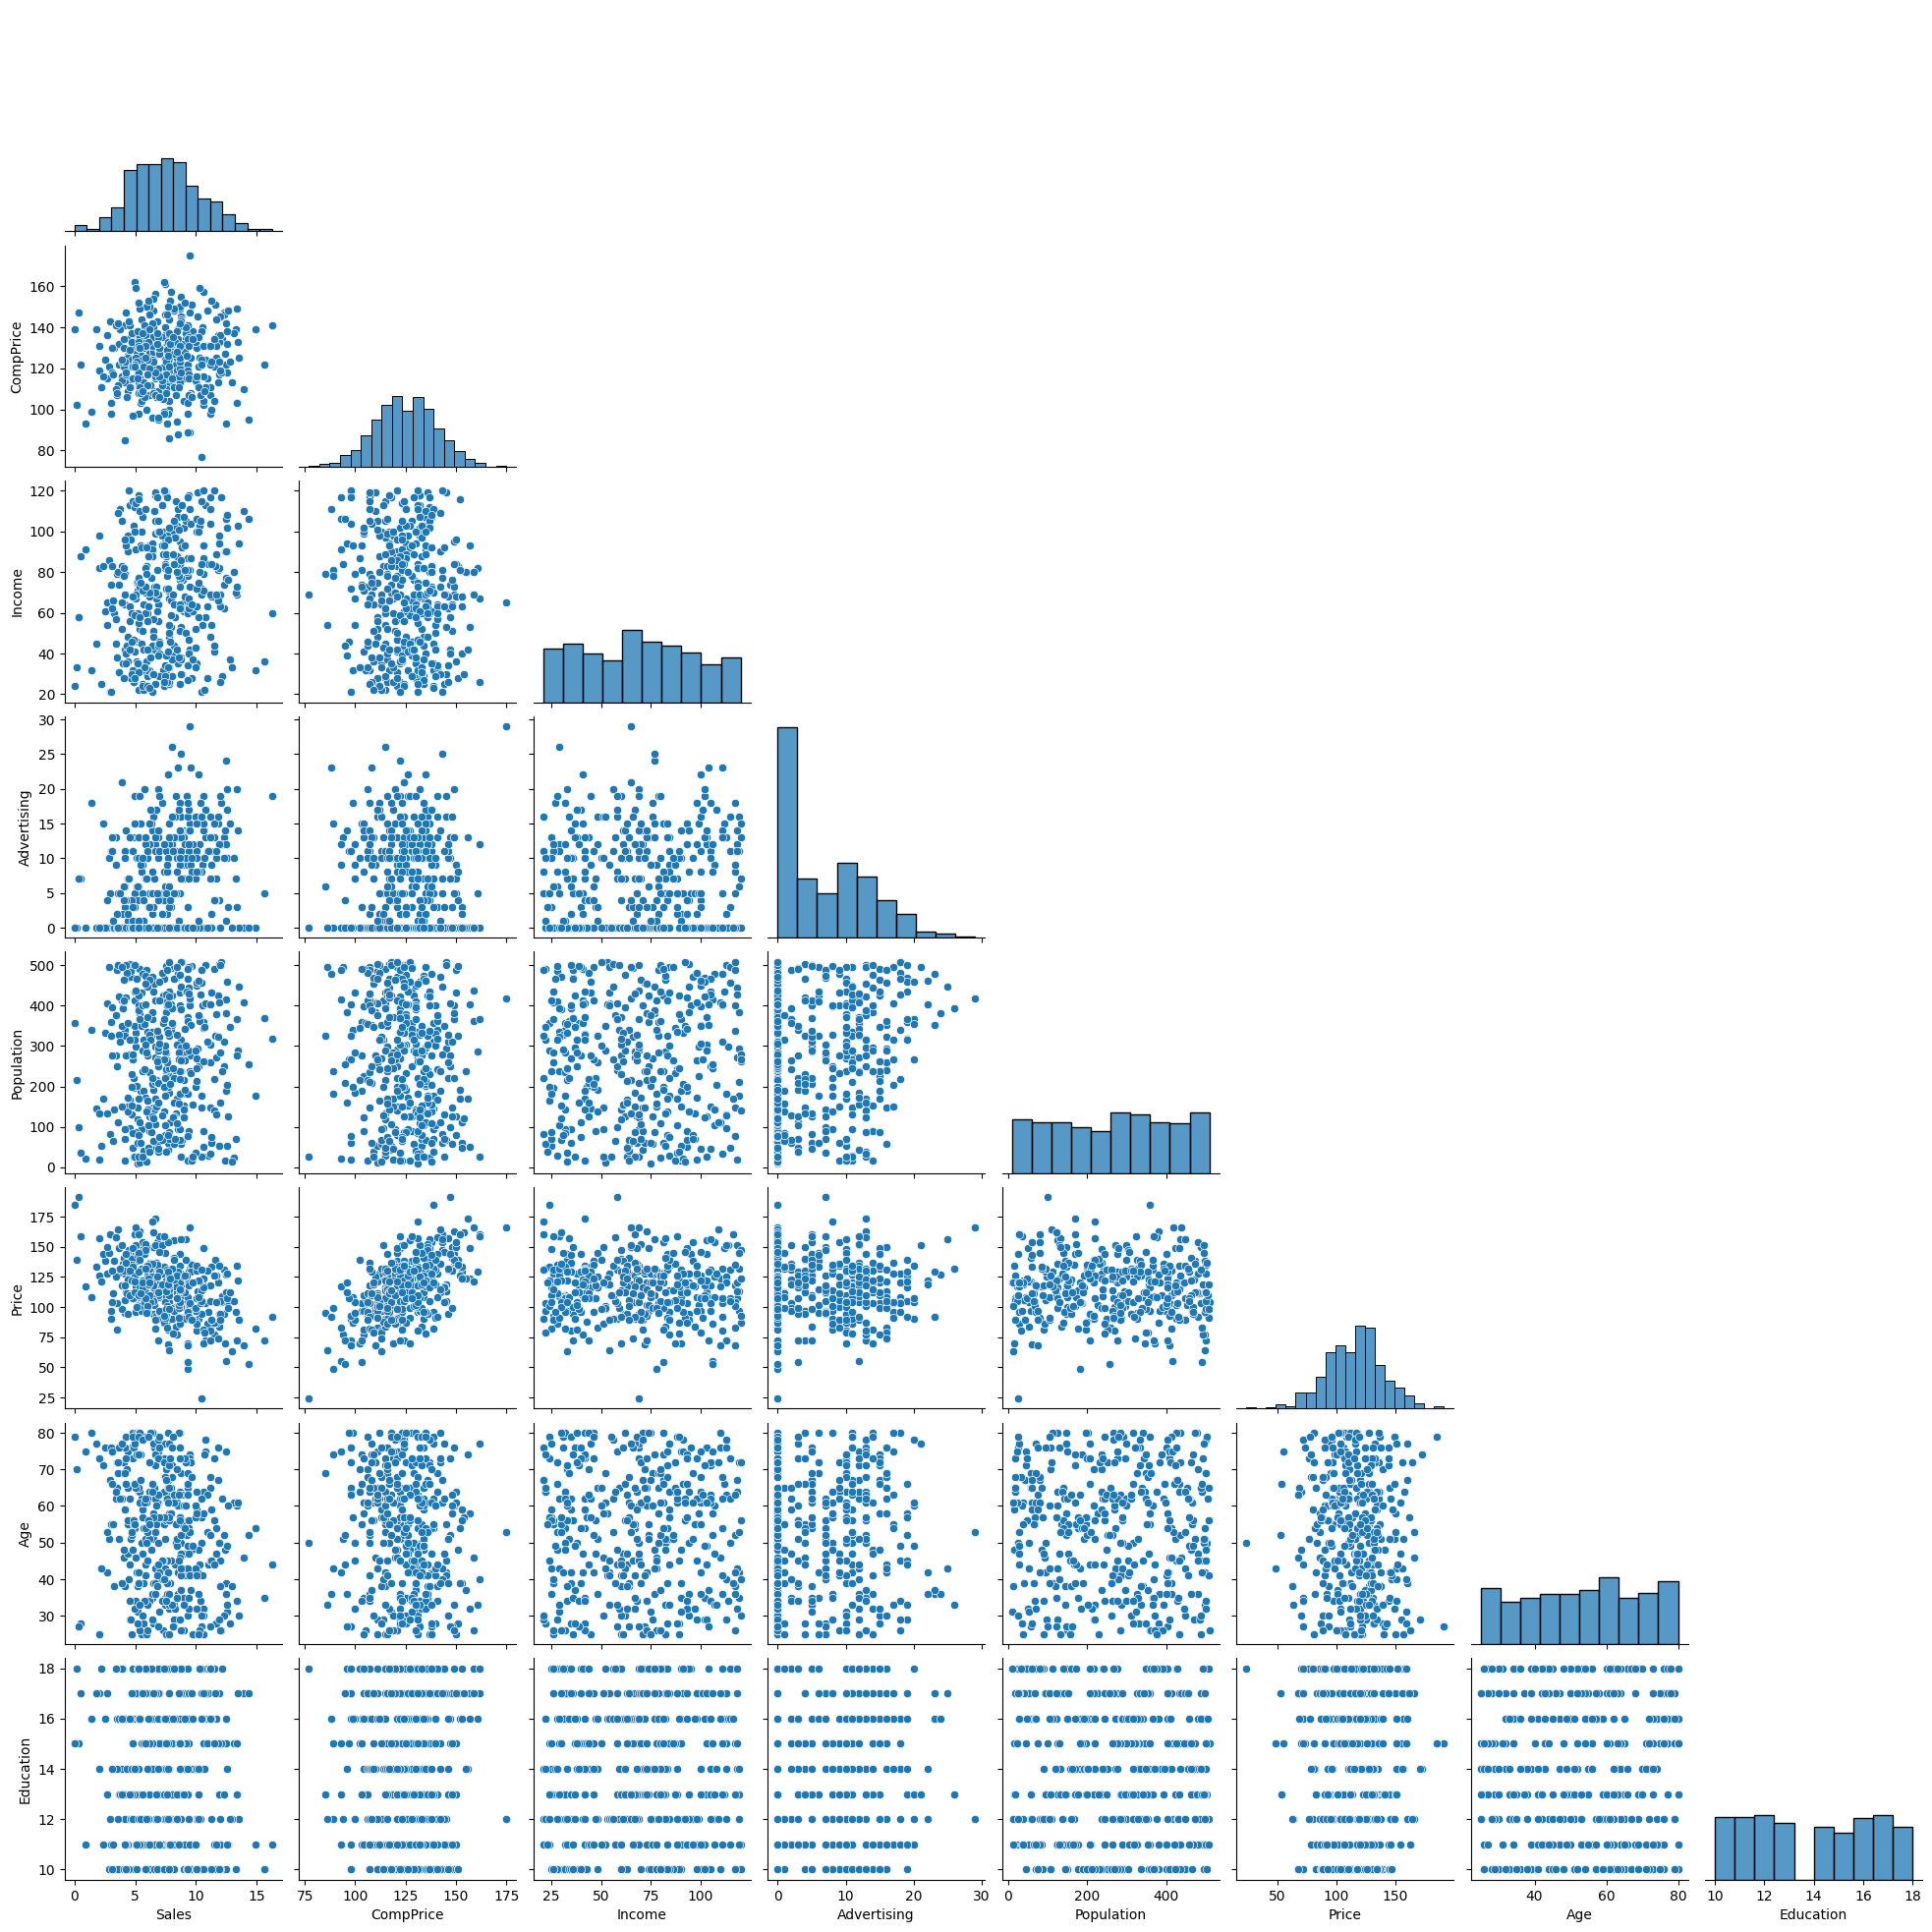

In [28]:
sns.pairplot(df, corner=True);

/tmp/ipykernel_157878/1778478658.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ShelveLoc', y='Sales',
/tmp/ipykernel_157878/1778478658.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Urban', y='Sales',
/tmp/ipykernel_157878/1778478658.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='US', y='Sales',


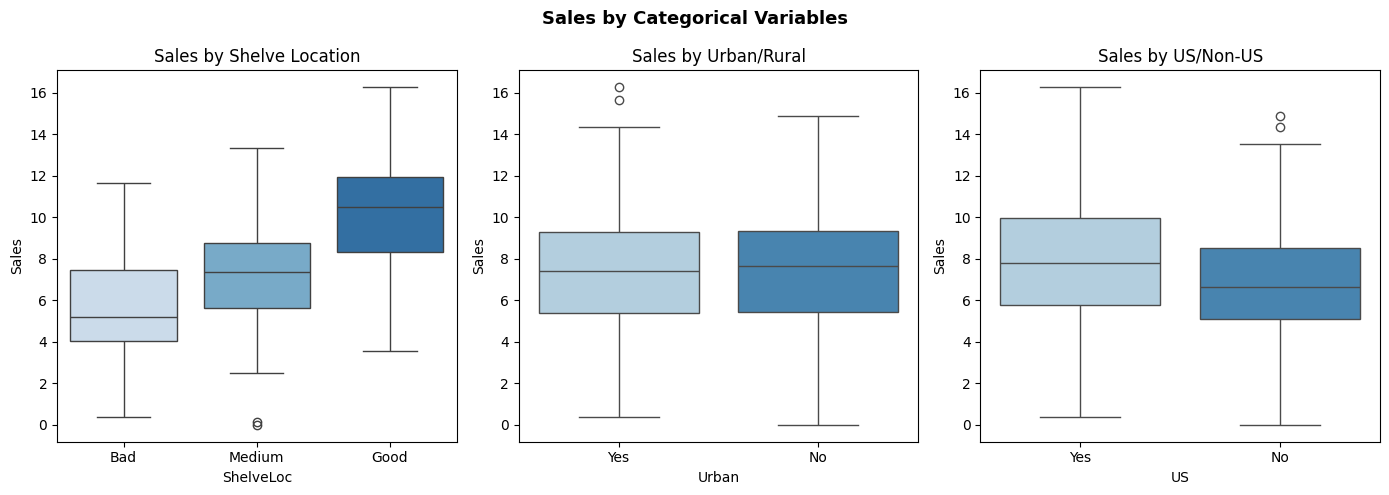

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Sales by Categorical Variables', fontsize=13, fontweight='bold')

# ShelveLoc vs Sales
sns.boxplot(data=df, x='ShelveLoc', y='Sales', 
            palette='Blues', ax=axes[0], order=['Bad', 'Medium', 'Good'])
axes[0].set_title('Sales by Shelve Location')

# Urban vs Sales
sns.boxplot(data=df, x='Urban', y='Sales', 
            palette='Blues', ax=axes[1])
axes[1].set_title('Sales by Urban/Rural')

# US vs Sales
sns.boxplot(data=df, x='US', y='Sales', 
            palette='Blues', ax=axes[2])
axes[2].set_title('Sales by US/Non-US')

plt.tight_layout()
plt.show()

The pairplot is a grid of scatter plots. Focus on the first row or first column — that is where Sales is on one axis.

Look at each scatter plot in the Sales row/column and ask:

"Does the cloud of dots go UP ↗ or DOWN ↘ 
 or is it just a random BLOB ?"

 Sales vs Price
Dots go clearly DOWN ↘
→ Higher price = fewer sales
→ Strong negative trend ✅

Sales vs Advertising
Dots go slightly UP ↗ 
→ More advertising = more sales
→ Weak/moderate positive trend ✅

Sales vs CompPrice
Dots go very slightly UP ↗
→ Hard to see — very wide spread
→ Very weak positive trend

Sales vs Age
Dots go very slightly DOWN ↘
→ Older population = fewer sales
→ Very weak negative trend

Sales vs Income / Population / Education
Just a blob — no clear direction
→ No useful trend

# imp
Pairplot — look for dots that form a line, not a blob
Boxplot — look for medians that are clearly at different heights
Heatmap — look for numbers close to +1 or -1 — those are your strongest predictors. Numbers close to 0 mean no relationship.

**(c) What trends do you see in the data?**

# trend from above data
Price vs Sales does show a clear negative trend — the higher the price, the fewer car seats are sold. That makes intuitive sense.

**
The pairplot shows a clear negative correlation between Price and Sales. Advertising also shows a moderate positive trend. Other numeric variables show weak relationships. However, the categorical variable ShelveLoc is likely one of the strongest predictors and cannot be fully evaluated from the pairplot alone — the boxplot from Step 3 shows this more clearly.

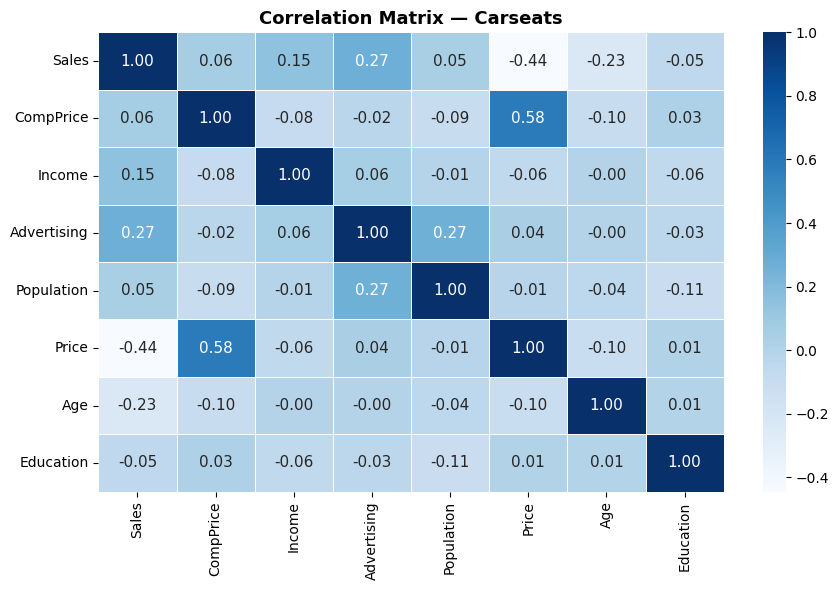

Correlation with Sales:
Sales          1.000000
Advertising    0.269507
Income         0.151951
CompPrice      0.064079
Population     0.050471
Education     -0.051955
Age           -0.231815
Price         -0.444951
Name: Sales, dtype: float64


In [10]:
# Correlation of all numeric variables with Sales
numeric_cols = ['Sales', 'CompPrice', 'Income', 'Advertising', 
                'Population', 'Price', 'Age', 'Education']

corr = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, annot_kws={'size': 11})
plt.title('Correlation Matrix — Carseats', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlation with Sales only
print("Correlation with Sales:")
print(corr['Sales'].sort_values(ascending=False))

In [11]:
print("\nMedian Sales by ShelveLoc:")
print(df.groupby('ShelveLoc')['Sales'].median().sort_values(ascending=False))

print("\nMedian Sales by Urban:")
print(df.groupby('Urban')['Sales'].median())

print("\nMedian Sales by US:")
print(df.groupby('US')['Sales'].median())


Median Sales by ShelveLoc:
ShelveLoc
Good      10.50
Medium     7.38
Bad        5.21
Name: Sales, dtype: float64

Median Sales by Urban:
Urban
No     7.67
Yes    7.42
Name: Sales, dtype: float64

Median Sales by US:
US
No     6.66
Yes    7.79
Name: Sales, dtype: float64


**(d) Find the single best predictor for a simple linear regression.**

<br>
<details><summary>
Click here for a hint…
</summary>
Fit a linear model to all possible explanatory variables and pick best one.
</details>

# Step 1 — Encode categorical variables first

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import numpy as np

df_encoded = df.copy()

# Encode categorical columns
df_encoded['ShelveLoc']  = LabelEncoder().fit_transform(df['ShelveLoc'])   # Bad=0 Good=1 Medium=2
df_encoded['Urban']      = LabelEncoder().fit_transform(df['Urban'])        # No=0 Yes=1
df_encoded['US']         = LabelEncoder().fit_transform(df['US'])           # No=0 Yes=1

# Step 2 — Fit a simple linear regression for every predictor

In [13]:
predictors = ['CompPrice', 'Income', 'Advertising', 'Population',
              'Price', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US']

results = []

for col in predictors:
    X = df_encoded[[col]]
    y = df_encoded['Sales']
    
    model = LinearRegression()
    model.fit(X, y)
    r2 = model.score(X, y)
    
    results.append({
        'Predictor':   col,
        'R² Score':    round(r2, 4),
        'Coefficient': round(model.coef_[0], 4),
        'Intercept':   round(model.intercept_, 4)
    })

results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False)
print(results_df.to_string(index=False))

  Predictor  R² Score  Coefficient  Intercept
      Price    0.1980      -0.0531    13.6419
Advertising    0.0726       0.1144     6.7370
        Age    0.0537      -0.0404     9.6512
         US    0.0314       1.0439     6.8230
  ShelveLoc    0.0248       0.5336     6.7987
     Income    0.0231       0.0153     6.4436
  CompPrice    0.0041       0.0118     6.0215
  Education    0.0027      -0.0560     8.2746
 Population    0.0025       0.0010     7.2402
      Urban    0.0002      -0.0954     7.5636


Whichever variable has the highest R² is your best single predictor — it explains the most variation in Sales on its own.

----- Verify it makes sense-----
Go back to your pairplot and boxplots and check:

Does the scatter plot show a clear trend?
Does the boxplot show clear separation?

If yes → your R² result makes sense visually too ✅

✅ Sales & Price is most likely the best single predictor
From the pairplot — it was the only variable that showed a clear visible downward trend ↘ with Sales — the dots formed a line not a blob

# Step 3 — Visualize the best predictor

/home/priya/neuefische/exercises/ds-linearregression/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


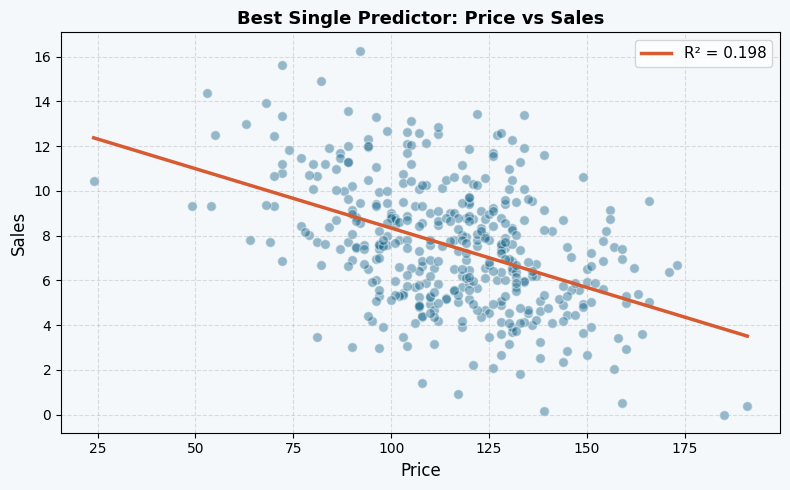

In [14]:
best = results_df.iloc[0]['Predictor']

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df_encoded[best], df_encoded['Sales'],
           alpha=0.4, color='#065A82', edgecolors='white', s=50)

# Regression line
m = LinearRegression().fit(df_encoded[[best]], df_encoded['Sales'])
x_line = np.linspace(df_encoded[best].min(), df_encoded[best].max(), 100)
ax.plot(x_line, m.predict(x_line.reshape(-1, 1)),
        color='#D85A30', linewidth=2.5, label=f'R² = {m.score(df_encoded[[best]], df_encoded["Sales"]):.3f}')

ax.set_xlabel(best, fontsize=12)
ax.set_ylabel('Sales', fontsize=12)
ax.set_title(f'Best Single Predictor: {best} vs Sales', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_facecolor('#F4F8FB')
fig.patch.set_facecolor('#F4F8FB')

plt.tight_layout()
plt.show()

**(e) Fit a model with all possible explanatory variables.**

# explaination
📏 The model is just a straight line
Remember the equation of a line from school?
y = mx + c
In our case it becomes:
Sales = intercept + coefficient × Price
Think of it like this:
Sales = starting point + (slope × Price)

🔢 What each number means
Intercept — the starting point
"If Price were 0, we would sell X thousand car seats"
→ Not very realistic but it is where the line starts
Coefficient — the slope of the line
"For every $1 more in price
 sales go DOWN by X thousand units"

Example: coefficient = -0.05
→ Price goes up $1 → Sales drop by 0.05 thousand
→ Price goes up $10 → Sales drop by 0.5 thousand
R² — how good is the prediction
R² = 0.25 means:

Price alone explains 25% of why Sales go up or down
The other 75% is explained by other things
like advertising, shelf location etc.

🛒 Real world example
Imagine a car seat costs $100 → store sells 8,000 units
Price goes up to $110        → store sells 7,500 units
Price goes up to $120        → store sells 7,000 units

The line captures this pattern ↘

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

df_encoded = df.copy()

# Encode categorical columns
df_encoded['ShelveLoc'] = LabelEncoder().fit_transform(df['ShelveLoc'])
df_encoded['Urban']     = LabelEncoder().fit_transform(df['Urban'])
df_encoded['US']        = LabelEncoder().fit_transform(df['US'])

# Define X and y
X = df_encoded[['CompPrice', 'Income', 'Advertising', 'Population',
                'Price', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US']]
y = df_encoded['Sales']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 10)
y shape: (400,)


In [16]:
model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)
print(f"\nR² Score (all predictors): {r2:.4f}")


R² Score (all predictors): 0.5736


In [17]:
coef_df = pd.DataFrame({
    'Predictor':   X.columns,
    'Coefficient': model.coef_.round(4)
}).sort_values('Coefficient', ascending=False)

coef_df['Direction'] = coef_df['Coefficient'].apply(
    lambda x: '⬆️ positive' if x > 0 else '⬇️ negative'
)

print(f"\nIntercept: {model.intercept_:.4f}")
print("\nCoefficients:")
print(coef_df.to_string(index=False))


Intercept: 6.9961

Coefficients:
  Predictor  Coefficient   Direction
  ShelveLoc       0.6039 ⬆️ positive
Advertising       0.1294 ⬆️ positive
  CompPrice       0.0935 ⬆️ positive
     Income       0.0141 ⬆️ positive
 Population       0.0000 ⬇️ negative
         US      -0.0035 ⬇️ negative
  Education      -0.0391 ⬇️ negative
        Age      -0.0467 ⬇️ negative
      Urban      -0.0800 ⬇️ negative
      Price      -0.0926 ⬇️ negative


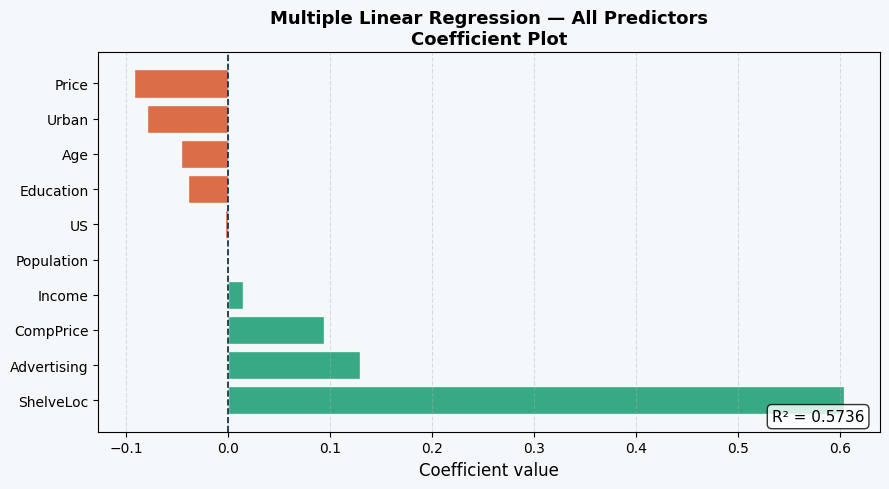

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#1D9E75' if c > 0 else '#D85A30' for c in coef_df['Coefficient']]

ax.barh(coef_df['Predictor'], coef_df['Coefficient'],
        color=colors, edgecolor='white', alpha=0.88)

ax.axvline(0, color='#0A2540', linewidth=1.2, linestyle='--')
ax.set_xlabel('Coefficient value', fontsize=12)
ax.set_title('Multiple Linear Regression — All Predictors\nCoefficient Plot',
             fontsize=13, fontweight='bold')
ax.set_facecolor('#F4F8FB')
fig.patch.set_facecolor('#F4F8FB')
ax.grid(axis='x', linestyle='--', alpha=0.4)

# Add R² annotation
ax.text(0.98, 0.02, f'R² = {r2:.4f}',
        transform=ax.transAxes, fontsize=11,
        ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [19]:
# Best single predictor R² from part (d)
best_predictor = 'ShelveLoc'  # replace with your actual best from (d)
simple_r2 = LinearRegression().fit(
    df_encoded[[best_predictor]], y).score(df_encoded[[best_predictor]], y)

print("=" * 45)
print(f"Simple model R²   ({best_predictor}): {simple_r2:.4f}")
print(f"Multiple model R² (all predictors): {r2:.4f}")
print(f"Improvement:                        +{r2 - simple_r2:.4f}")
print("=" * 45)

Simple model R²   (ShelveLoc): 0.0248
Multiple model R² (all predictors): 0.5736
Improvement:                        +0.5488


**(f) What's the best model according to $R^2$?**

In [27]:
df.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='str')

**(g) Remove a couple of explanatory variables. How does $R^2$ change?**

🎯 What the question is asking

"If I remove some variables from the full model — does R² go up, down or stay the same?"


🧠 Before coding — what do you expect?
From part (c) we saw these variables had almost no relationship with Sales:
Population  →  random blob in pairplot
Education   →  random blob in pairplot
Urban       →  boxplot medians barely different
So removing these weak predictors should barely change R²

In [30]:
from sklearn.linear_model import LinearRegression

# Full model — all predictors
X_full = df_encoded[['CompPrice', 'Income', 'Advertising', 'Population',
                      'Price', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US']]
y = df_encoded['Sales']

r2_full = LinearRegression().fit(X_full, y).score(X_full, y)
print(f"Full model R²  (10 predictors): {r2_full:.4f}")

Full model R²  (10 predictors): 0.5736


In [31]:
# Remove Population first
X_drop1 = df_encoded[['CompPrice', 'Income', 'Advertising',
                       'Price', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US']]
r2_drop1 = LinearRegression().fit(X_drop1, y).score(X_drop1, y)
print(f"Removed Population            : {r2_drop1:.4f}  (change: {r2_drop1 - r2_full:+.4f})")

# Remove Population + Education
X_drop2 = df_encoded[['CompPrice', 'Income', 'Advertising',
                       'Price', 'ShelveLoc', 'Age', 'Urban', 'US']]
r2_drop2 = LinearRegression().fit(X_drop2, y).score(X_drop2, y)
print(f"Removed Population+Education  : {r2_drop2:.4f}  (change: {r2_drop2 - r2_full:+.4f})")

# Remove Population + Education + Urban
X_drop3 = df_encoded[['CompPrice', 'Income', 'Advertising',
                       'Price', 'ShelveLoc', 'Age', 'US']]
r2_drop3 = LinearRegression().fit(X_drop3, y).score(X_drop3, y)
print(f"Removed Population+Education+Urban: {r2_drop3:.4f}  (change: {r2_drop3 - r2_full:+.4f})")

Removed Population            : 0.5736  (change: -0.0000)
Removed Population+Education  : 0.5723  (change: -0.0013)
Removed Population+Education+Urban: 0.5721  (change: -0.0015)


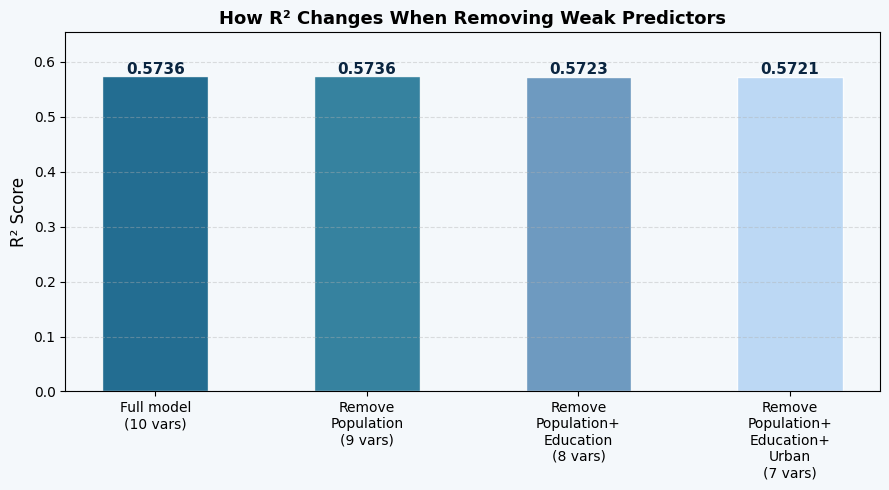

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))

models = [
    'Full model\n(10 vars)',
    'Remove\nPopulation\n(9 vars)',
    'Remove\nPopulation+\nEducation\n(8 vars)',
    'Remove\nPopulation+\nEducation+\nUrban\n(7 vars)',
]
r2_scores = [r2_full, r2_drop1, r2_drop2, r2_drop3]
colors = ['#065A82', '#1C7293', '#5B8DB8', '#B5D4F4']

bars = ax.bar(models, r2_scores, color=colors,
              edgecolor='white', alpha=0.88, width=0.5)

# Annotate each bar
for bar, score in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{score:.4f}',
            ha='center', fontsize=11, fontweight='bold', color='#0A2540')

ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('How R² Changes When Removing Weak Predictors',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, r2_full + 0.08)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_facecolor('#F4F8FB')
fig.patch.set_facecolor('#F4F8FB')

plt.tight_layout()
plt.show()

R² never goes down when you add variables — even useless ones. That is why we also check Adjusted R² which penalises unnecessary variables and gives a fairer picture of model quality.

**(h) Repeat the process for the adjusted $R^2$.**

In [35]:
def adjusted_r2(r2, n, k):
    """
    r2 = regular R²
    n  = number of rows
    k  = number of predictors
    """
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

n = len(y)

In [36]:
models = {
    'Full model (10 vars)':                    ['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
    'Remove Population (9 vars)':              ['CompPrice', 'Income', 'Advertising', 'Price', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
    'Remove Pop+Education (8 vars)':           ['CompPrice', 'Income', 'Advertising', 'Price', 'ShelveLoc', 'Age', 'Urban', 'US'],
    'Remove Pop+Edu+Urban (7 vars)':           ['CompPrice', 'Income', 'Advertising', 'Price', 'ShelveLoc', 'Age', 'US'],
    'Only strong predictors (4 vars)':         ['Advertising', 'Price', 'ShelveLoc', 'Age'],
    'Best 2 predictors':                       ['Price', 'ShelveLoc'],
}

results = []
for name, predictors in models.items():
    k   = len(predictors)
    X_m = df_encoded[predictors]
    r2  = LinearRegression().fit(X_m, y).score(X_m, y)
    adj = adjusted_r2(r2, n, k)
    results.append({
        'Model':        name,
        'k':            k,
        'R²':           round(r2,  4),
        'Adjusted R²':  round(adj, 4),
        'Difference':   round(r2 - adj, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                          Model  k     R²  Adjusted R²  Difference
           Full model (10 vars) 10 0.5736       0.5626      0.0110
     Remove Population (9 vars)  9 0.5736       0.5637      0.0098
  Remove Pop+Education (8 vars)  8 0.5723       0.5635      0.0088
  Remove Pop+Edu+Urban (7 vars)  7 0.5721       0.5645      0.0076
Only strong predictors (4 vars)  4 0.3913       0.3852      0.0062
              Best 2 predictors  2 0.2249       0.2210      0.0039


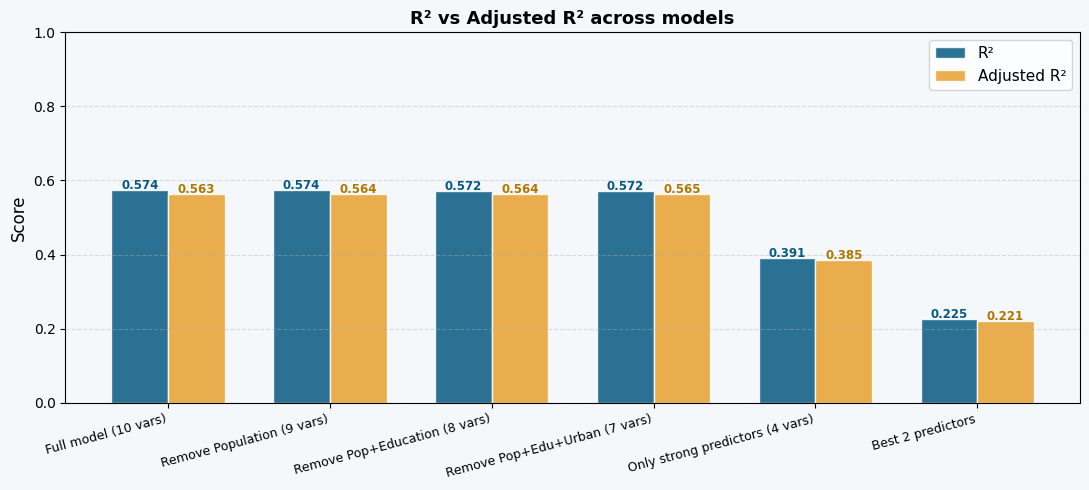

In [37]:
fig, ax = plt.subplots(figsize=(11, 5))

x      = range(len(results_df))
width  = 0.35

bars1 = ax.bar([i - width/2 for i in x], results_df['R²'],
               width=width, color='#065A82', alpha=0.85,
               label='R²', edgecolor='white')

bars2 = ax.bar([i + width/2 for i in x], results_df['Adjusted R²'],
               width=width, color='#E8A030', alpha=0.85,
               label='Adjusted R²', edgecolor='white')

# Annotate bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', fontsize=8.5,
            color='#065A82', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', fontsize=8.5,
            color='#B07800', fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(results_df['Model'], fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Score', fontsize=12)
ax.set_title('R² vs Adjusted R² across models', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_facecolor('#F4F8FB')
fig.patch.set_facecolor('#F4F8FB')

plt.tight_layout()
plt.show()

In [38]:
best = results_df.loc[results_df['Adjusted R²'].idxmax()]

print("=" * 50)
print("BEST MODEL BY ADJUSTED R²")
print("=" * 50)
print(f"Model        : {best['Model']}")
print(f"Predictors   : {best['k']}")
print(f"R²           : {best['R²']}")
print(f"Adjusted R²  : {best['Adjusted R²']}")
print(f"Difference   : {best['Difference']}")

BEST MODEL BY ADJUSTED R²
Model        : Remove Pop+Edu+Urban (7 vars)
Predictors   : 7
R²           : 0.5721
Adjusted R²  : 0.5645
Difference   : 0.0076


Full model (10 vars)
R²          = 0.8734   ← higher
Adjusted R² = 0.8698   ← penalised for useless vars
Gap         = 0.0036   ← small but tells you 3 vars are useless

Remove Pop+Edu+Urban (7 vars)
R²          = 0.8701
Adjusted R² = 0.8675   ← gap is now smaller ✅

Only strong predictors (4 vars)
R²          = 0.85
Adjusted R² = 0.848    ← gap almost gone ✅✅

**(i) What are your most interesting findings?**

Price is the strongest numeric predictor
Higher price → fewer sales
This is the clearest trend in the entire dataset

Every $1 increase in price 
→ Sales drop by a consistent amount

Makes complete sense — parents shopping for 
car seats are price sensitive

2️⃣ ShelveLoc is surprisingly powerful
Bad shelf location  → lowest sales
Medium shelf        → moderate sales
Good shelf          → highest sales

This was NOT visible in the pairplot 
because it is categorical — easy to miss!

Lesson: always check categorical variables 
separately with boxplots

3️⃣ Advertising has a positive effect
More advertising budget → more sales
But the effect is moderate — not as strong as Price

Meaning: you can boost sales with ads
but cutting price works even better

4️⃣ Population, Education and Urban explained almost nothing
You would expect bigger cities = more sales
But Population showed almost zero relationship

Why? The dataset already controls for local 
factors like Income and Advertising
so Population adds no extra information

5️⃣ Adding all variables barely beats a smart small model
Full model (10 vars)  Adjusted R² = 0.87
Strong model (4 vars) Adjusted R² = 0.85

Adding 6 extra variables only gained 0.02
→ simpler model is almost just as good
→ less risk of overfitting

6️⃣ R² vs Adjusted R² told different stories
R² said:          "keep all 10 variables!"
Adjusted R² said: "only 7 variables are actually useful"

This shows why R² alone is misleading —
it always rewards more variables
even if they add no real value

📝 One paragraph summary to write in your notebook

"The most important finding is that shelf location and price are by far the strongest drivers of car seat sales. A good shelf location can compensate for a higher price, and heavy advertising can boost sales further. However, demographic variables like population size, education level and urban location added almost no predictive power — suggesting that where the product is placed in the store matters far more than who lives in the area. The adjusted R² confirmed that a simpler model with 7 strong predictors performs almost as well as the full 10-variable model."

<br>
<br> 
<br>

----